### Student Name:

In [181]:
import re

import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
from vega_datasets import data

from fuzzywuzzy import fuzz
from fuzzywuzzy import process

from wordcloud import WordCloud
from PIL import Image

### Part 1: Text Improvement

Return to an early assignment submission that you have made (just one plot). Reproduce it here. Then, create a *revised* version that is the best possible use of text. Make sure to use proper axis labels, tick labels, legend items, title, and subtitle if applicable. Include a descriptive general-audience caption that contains all necessary information to understand and interpret the plot.

Refer to the customization and saving demo notebook for syntax help.

In [182]:
cars = "https://cdn.jsdelivr.net/npm/vega-datasets@1/data/cars.json"

alt.Chart(cars).transform_filter(
    "datum.Cylinders==8 & year(datum.Year)== 1975"
).mark_bar().encode(
    alt.X("Weight_in_lbs:Q", title="Weight (lbs)"),
    alt.Y("Name:N", sort = alt.Sort(field="Acceleration")),
    color=alt.Color("Acceleration:Q").bin()
).properties(
    title="Original"
)

alt.Chart(...)

In [183]:
revised_car_base = alt.Chart(
    cars,
    title=alt.Title(
        text="Weight vs. Acceleration for 8-Cylinder Cars in 1975",
        subtitle="Heavier cars actually accelerate faster",
    ),
).transform_filter(
    "datum.Cylinders==8 & year(datum.Year)==1975"
).mark_point().encode(
    alt.X("Weight_in_lbs:Q", title="Vehicle Weight (lbs)", scale=alt.Scale(domain=(3000, 5000))),
    alt.Y("Acceleration:Q", title="0–60 mph Acceleration Time (seconds)", scale=alt.Scale(domain=(11, 16))),
    alt.Color("Name:N", legend=None),
)

revised_car_text = revised_car_base.mark_text(
    align=alt.expr('datum.Name == "dodge coronet brougham" ? "right" : "left"'),
    baseline="middle",
    dx=alt.expr('datum.Name == "dodge coronet brougham" ? -7 : 7'),
).encode(
    text="Name:N",
    color=alt.Color("Name:N", legend=None),
)

(revised_car_base + revised_car_text).properties(
    width=500,
    height=500,
)

alt.LayerChart(...)

### Caption
The horizontal axis shows vehicle weight in pounds ranging from 3000 to 5000 lbs, and the vertical axis shows 0 to 60 mph acceleration time in seconds, lower the better.
Each point is labeled with the car's name and color-coded uniquely.
The chart shows a negative correlation between weight and acceleration time, that lighter cars not necessarily faster.
Heavier cars such as Chevy C10 and Cadillac Seville have the fastest acceleration, while lighter models like the Ford F108 has the slowest acceleration.
So heavier cars are actually more powerful.

### Part 2: Data Exploration

In [184]:
df = pd.read_csv("https://data.seattle.gov/resource/jguv-t9rb.csv?$limit=20000")
df.head()

,license_issue_date,license_number,animal_s_name,species,primary_breed,secondary_breed,zip_code
0,2015-12-18T00:00:00.000,S107948,Zen,Cat,Domestic Longhair,Mix,98117
1,2016-06-14T00:00:00.000,S116503,Misty,Cat,Siberian,NaN,98117
2,2016-08-04T00:00:00.000,S119301,Lyra,Cat,Mix,NaN,98121
3,2020-11-20T00:00:00.000,077412,Gemma,Cat,Siamese,American Shorthair,98126
4,2022-02-10T00:00:00.000,S149283,Edgar,Cat,Domestic Shorthair,Mix,98126


In [185]:
set(list(df["species"]))

{'Cat', 'Dog', 'Goat', 'Pig'}

#### Step 1:
Make a word cloud of the names and/or breeds. Be sure to apply string manipulation if necessary to show the data accurately.

In [186]:
list(set(list(df["primary_breed"])))[:10]

['Terrier, Jack Russell',
 'Peruvian Inca Orchid',
 'Keeshond',
 'Belgian Sheepdog',
 'Braque Francais Pyrenees',
 'Poodle, Toy',
 'Schnauzer, Standard',
 'Pekingese',
 'Brittany',
 'Bernese Mountain Dog']

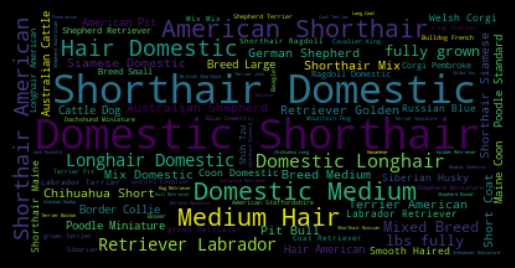

In [187]:
wordcloud = WordCloud().generate(" ".join(list(df["primary_breed"])))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

#### Step 2: Explore the Data

Explore the data by considering the following questions:
- How many unique names are there?
- Pick one name that might have multiple spellings. Are there similar names that are spelled differently? Use fuzzy matching to see which names might be similar.   
- How *many* names does each pet have? Is there a pattern you can pull out from that?
- Do any names stand out to you? For example, are there patterns in using certian prefixes to names, or name endings?
- Are there any common terms used in the breeds of the pets?

You are welcome to explore other patterns as well!

**Leave all your exploration steps here to show what you looked at, but be sure to clean up your code to show a final version of each exploration.**

In [188]:
# How many unique names are there?
unique_name = set(list(df["animal_s_name"].dropna()))
print("Unique Names:", len(unique_name))

Unique Names: 7930


In [189]:
sorted(list(unique_name))[:10]

['!zzy',
 "'Alani",
 '(Baboo)',
 '2 Chainz',
 '6-Toes',
 '99',
 'A2-ROCKETT',
 'ABBY',
 'AJ',
 'ALLIE']

In [190]:
# Possible multiple spellings
process.extract(query="Alex", choices=list(unique_name), limit=10)

[('Alex', 100),
 ('Kasper Alexander', 90),
 ('Alexander', 90),
 ('Alexandra', 90),
 ('Bella Alexander', 90),
 ('Alexis', 90),
 ('Alex Paw Kitten', 90),
 ('Kai Alexander', 90),
 ('Alexa', 89),
 ('Clydesdale', 77)]

In [191]:
# How many names does each pet have? Is there a pattern you can pull out from that?
def is_multi_name(name: str):
    return name.find("(") > -1

multiple_names = [name for name in unique_name if is_multi_name(name)]
print("Pets with multiple names:", len(multiple_names))
print("Average number of names per pet:", (len(unique_name) + len(multiple_names)) / len(unique_name))
print(multiple_names[:20])
# Answer: each pet essentially has one name, and even for pets with multiple names, the nickname is often the abbreviated version of the full name

Pets with multiple names: 95
Average number of names per pet: 1.0119798234552333
['Moritz (Mori)', "Vax'ildan (Vax)", 'Minn (Minnesota)', 'Penelope (Ruth)', 'Nova Scotia (Lani)', 'Petra (Queen Lone Wolf)', 'Gauss Rifle (Gauss)', 'Eursulon (Bear)', 'Sumo (Mo)', 'Digby (Heidi)', 'Ellysetta Mouse Brindlewisp (Ellie)', 'Raspberry (Razz)', 'Mr Cat (Manuel)', 'Kacela (formerly Flurry)', 'Kiki (Hope)', 'Emmie (Mischief)', 'Cleo (formerly Pudgy}', 'Snickers ("Niki")', 'Cixi (Shi-Shi)', 'Tuffs (Previously: Geno)']


In [192]:
# Do any names stand out to you? For example, are there patterns in using certian prefixes to names, or name endings?
def is_special_name(name: str):
    return re.search(r"!|@|#|\$|%|\^|&|\*", name) is not None

special_names = [name for name in unique_name if is_special_name(name)]
print("Pets with unusual name:", len(special_names))
# Answer: there are some pet names with special characters to carry out information that's meant to be not part of the name
special_names

Pets with unusual name: 10


['Alakazam!',
 'Bailey *FREE ADOPTION FEE*',
 '!zzy',
 'Peru *FREE ADOPTION FEE*',
 'Lady *FREE ADOPTION FEE*',
 'Hocus Pocus!',
 'Willa *FREE ADOPTION FEE!*',
 'Amalie *NO ADOPTION FEE!*',
 'Tiramisu *FREE ADOPTION FEE*',
 'Athena *FREE ADOPTION FEE*']

In [193]:
# Are there any common terms used in the breeds of the pets?
breeds = sorted(list(set(list(df["primary_breed"]))))
name_freq_by_breed = df.groupby("primary_breed")["animal_s_name"].value_counts()

top_names_breed = {}
for breed in breeds:
    curr_breed = name_freq_by_breed[breed]
    curr_breed_top = curr_breed.head(1)
    curr_breed_top_count = int(curr_breed_top.iloc[0])
    if curr_breed_top_count > 1:
        top_names_breed[breed] = (curr_breed_top.index[0], curr_breed_top_count)

# Answer: for names that's the most common in a breed, it's possibly also a common name for that breed.
# for example, the name "Luna"and "Lucy" each appears at least 5 times throughout the breeds below.
list(top_names_breed.items())[:25]

[('Abyssinian', ('Cleo', 2)),
 ('Alaskan Husky', ('Luna', 3)),
 ('American Shorthair', ('Luna', 14)),
 ('Australian Cattle Dog', ('Luna', 5)),
 ('Australian Shepherd', ('Luna', 7)),
 ('Australian Shepherd, Miniature', ('Charlie', 4)),
 ('Balinese', ('Snoqualmie', 2)),
 ('Beagle', ('Lucy', 5)),
 ('Belgian Malinois', ('Maple', 2)),
 ('Bengal', ('Xena', 3)),
 ('Bernese Mountain Dog', ('Rosie', 3)),
 ('Bichon Frise', ('Daisy', 2)),
 ('Bombay', ('Salem', 5)),
 ('Border Collie', ('Millie', 4)),
 ('Boxer', ('Frankie', 2)),
 ('Brittany', ('Poppy', 2)),
 ('Bulldog', ('Zoe', 2)),
 ('Bulldog, French', ('Hazel', 3)),
 ('Chihuahua, Short Coat', ('Lily', 5)),
 ('Coton de Tulear', ('Daisy', 2)),
 ('Cur, Black-Mouth', ('Maggie', 2)),
 ('Dachshund, Standard Smooth Haired', ('Millie', 2)),
 ('Domestic Longhair', ('Lucy', 5)),
 ('Domestic Medium Hair', ('Milo', 11)),
 ('Domestic Shorthair', ('Luna', 65))]

#### Step 3: Make a Plot
Pick an interesting patterns that you found in your exploration above. Make a well-considered plot of this pattern. It does not need to be groundbreaking, but make sure it uses some kind of text manipulation from the above data. It should not be a word cloud but a regular Altair graphic (line, bar, scatterplot, etc).

**What one-sentence conclusion should we draw from this plot?**

> Luna is the most popular pet name in Seattle by a significant margin.

In [194]:
names_freq = df["animal_s_name"].value_counts()
top_names_freq = names_freq.head(10).to_dict()
print(top_names_freq)

top_names_variations = {}
for name in top_names_freq.keys():
    variations = process.extract(query=name, choices=list(unique_name), limit=5)
    variations = [variation for variation in variations if variation[1] >= 95]
    top_names_variations[name] = variations
print(top_names_variations)

normalized_top_names_freq = {}
for name, variations in top_names_variations.items():
    normalized_top_names_freq[name] = int(sum([names_freq[variation[0]] for variation in variations]))
print(normalized_top_names_freq)

normalized_top_names_freq_df = pd.DataFrame({
    "name": list(normalized_top_names_freq.keys()),
    "frequency": list(normalized_top_names_freq.values())
})

{'Luna': 245, 'Lucy': 153, 'Bella': 110, 'Penny': 105, 'Lily': 96, 'Daisy': 94, 'Ruby': 93, 'Olive': 83, 'Pepper': 81, 'Rosie': 80}
{'Luna': [('Luna', 100)], 'Lucy': [('Lucy', 100), ('LUCY', 100)], 'Bella': [('Bella', 100)], 'Penny': [('Penny', 100)], 'Lily': [('Lily', 100)], 'Daisy': [('Daisy', 100)], 'Ruby': [('Ruby', 100)], 'Olive': [('Olive', 100)], 'Pepper': [('Pepper', 100), ('PEPPER', 100)], 'Rosie': [('Rosie', 100)]}
{'Luna': 245, 'Lucy': 154, 'Bella': 110, 'Penny': 105, 'Lily': 96, 'Daisy': 94, 'Ruby': 93, 'Olive': 83, 'Pepper': 82, 'Rosie': 80}


In [195]:
alt.Chart(normalized_top_names_freq_df).mark_bar().encode(
    y=alt.Y("name:N", title="Pet Name", sort="-x"),
    x=alt.X("frequency:Q", title="Frequency"),
)

alt.Chart(...)

#### Step 4: Perfect and Save Your Plot
Take your plot from above and make it beautiful. Add a descriptive title, subtitle, and axes labels. Edit the fonts and styles to be attractive and well-sized. Add alt-text using the `description` argument and make sure it describes the data behind the plot.

In [196]:
bar_chart = alt.Chart(
    normalized_top_names_freq_df,
    title=alt.Title(
        text="Top 10 Most Popular Pet Names in Seattle",
        subtitle="Fuzzy-matched counts combine spelling variants (e.g. \"Luna\", \"LUNA\") from 20000 licensed pets",
    ),
    description=(
        "A horizontal bar chart showing the 10 most frequent pet names registered in Seattle. " +
        "Counts are aggregated using fuzzy string matching to combine near-identical spelling variants. " +
        "Luna is the most popular name with 245 appearance, followed by Bella and Charlie. " +
        "All names shown appear more than 50 times in the dataset."
    ),
).mark_bar().encode(
    y=alt.Y(
        "name:N",
        title=None,
        sort="-x",
    ),
    x=alt.X(
        "frequency:Q",
        title="Number of Registered Pets",
    ),
).properties(width=600, height=400)

text_overlay = bar_chart.mark_text(
    align="left",
    baseline="middle",
    dx=3,
).encode(
    text=alt.Text("frequency:Q"),
)

bar_chart + text_overlay

alt.LayerChart(...)